In [39]:
#Importing required packages
library(dplyr)
library(tidyverse)
library(gtsummary)
library(gt)
library(ggeffects)
library(reliabilitydiag)
library(pROC)
library(ggplot2)
library(patchwork)


df = read.csv('c_peptide_clean.csv')

In [40]:
#Correcting data formats and standardizing numeric variables
df$c_peptide_v1_z = as.numeric(scale(df$c_peptide_v1))
df$GAD_v1_z = as.numeric(scale(df$GAD_v1))
df$DKA = as.factor(df$DKA)
df$Gender_v1 =  as.factor(df$Gender_v1)
df$IA2_bin_v1 = as.factor(df$IA2_bin_v1)
df$c_peptide_status = as.factor(df$c_peptide_status)

#### Individual analysis on selected variables, adjusted for baseline hba1c

Setting levels: control = 0, case = 1

Setting direction: controls < cases

New names:
• `` -> `...1`
Setting levels: control = 0, case = 1

Setting direction: controls < cases



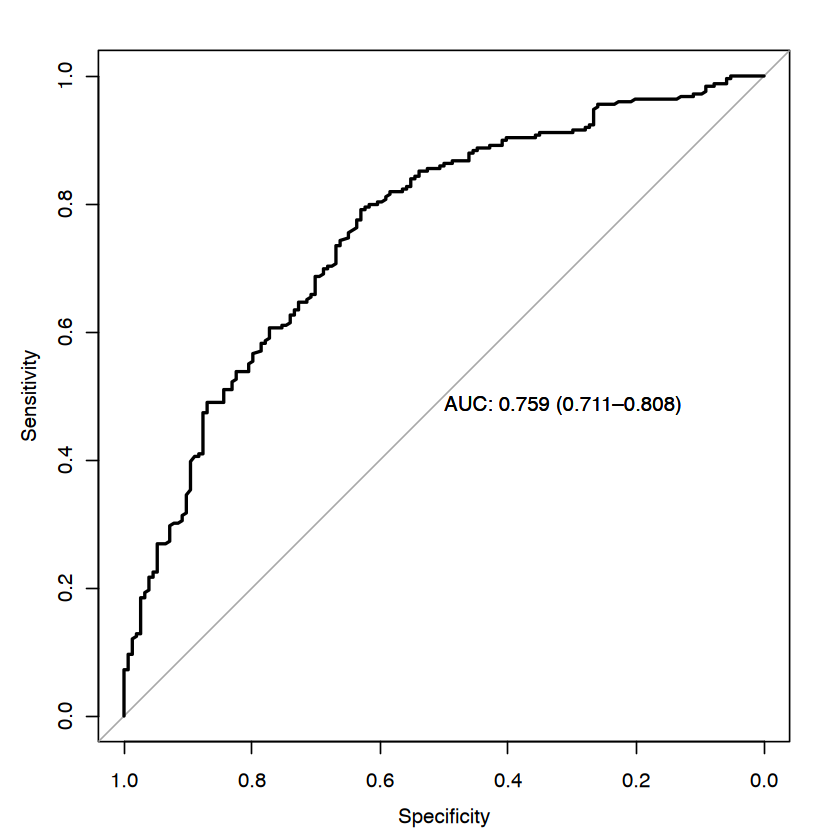

New names:
• `` -> `...1`
Setting levels: control = 0, case = 1

Setting direction: controls < cases



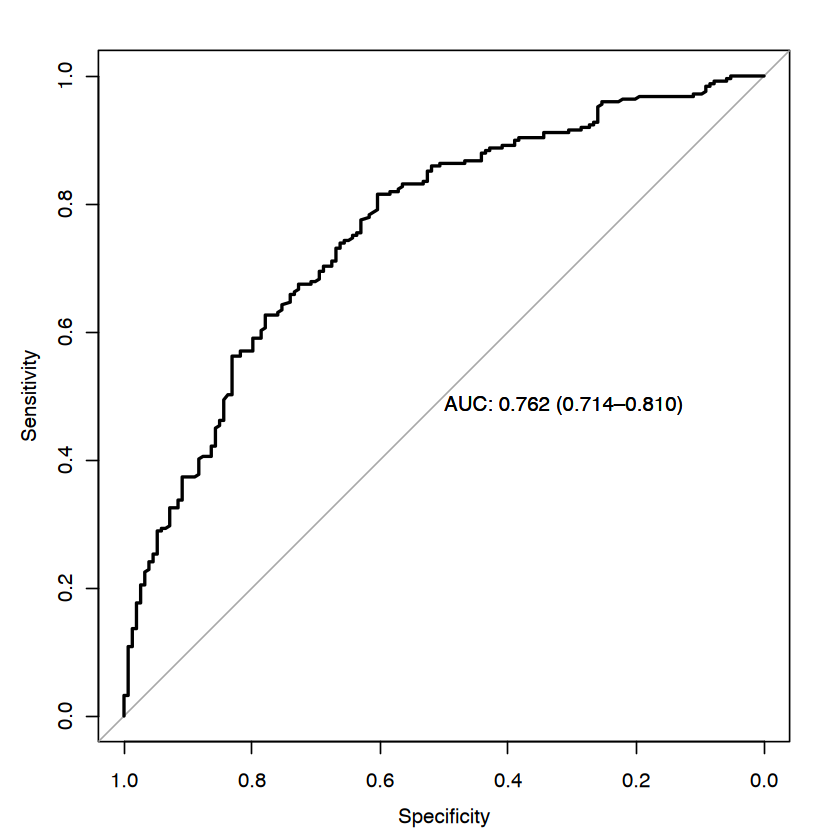

New names:
• `` -> `...1`
Setting levels: control = 0, case = 1

Setting direction: controls < cases



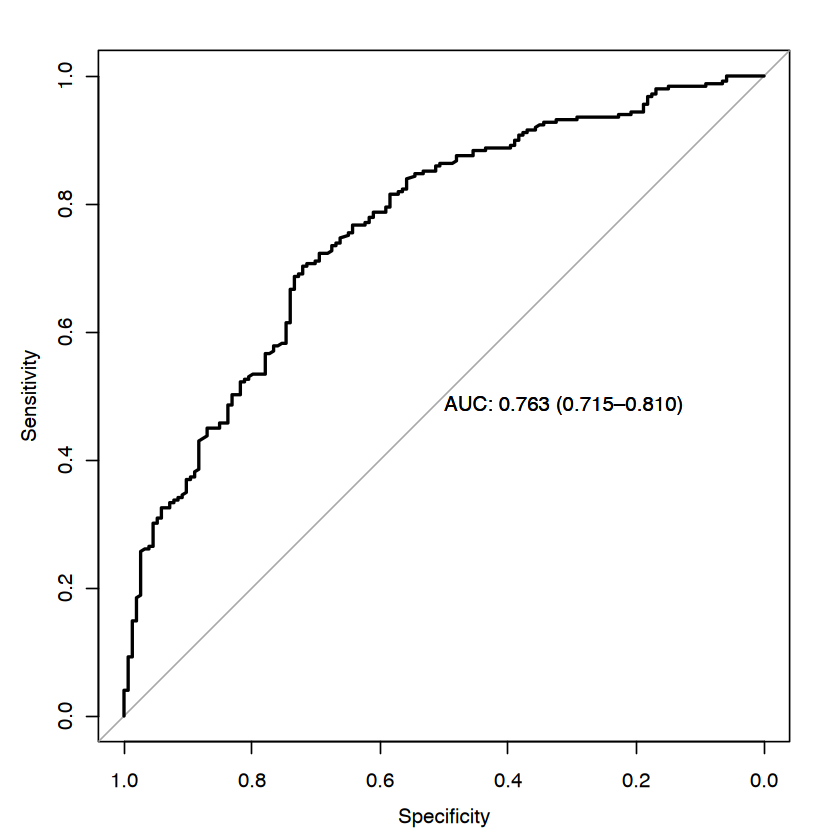

New names:
• `` -> `...1`
Setting levels: control = 0, case = 1

Setting direction: controls < cases



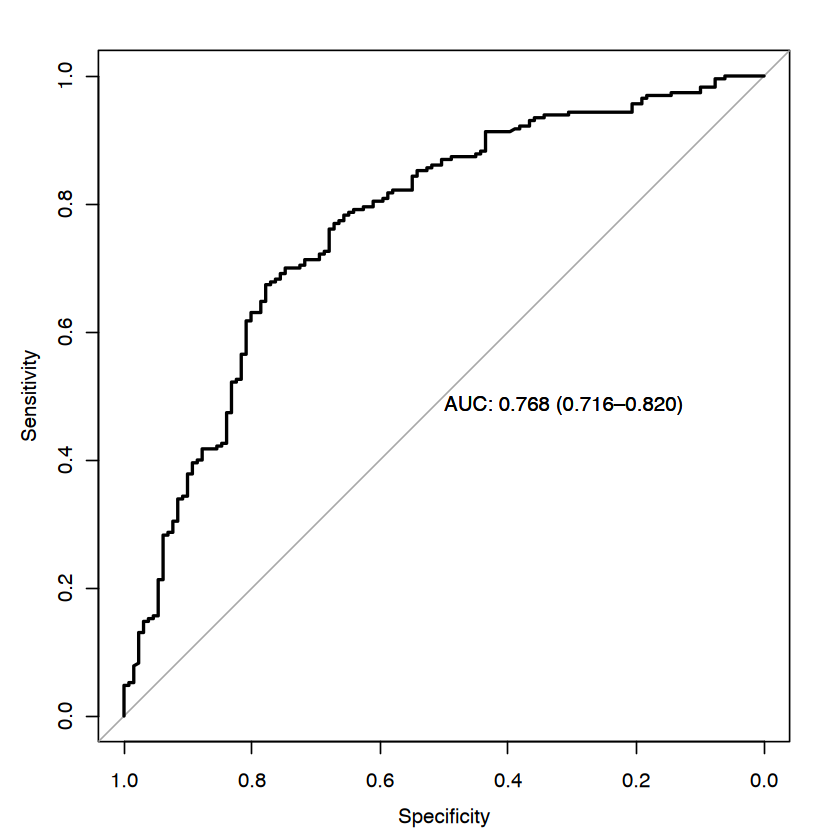

New names:
• `` -> `...1`


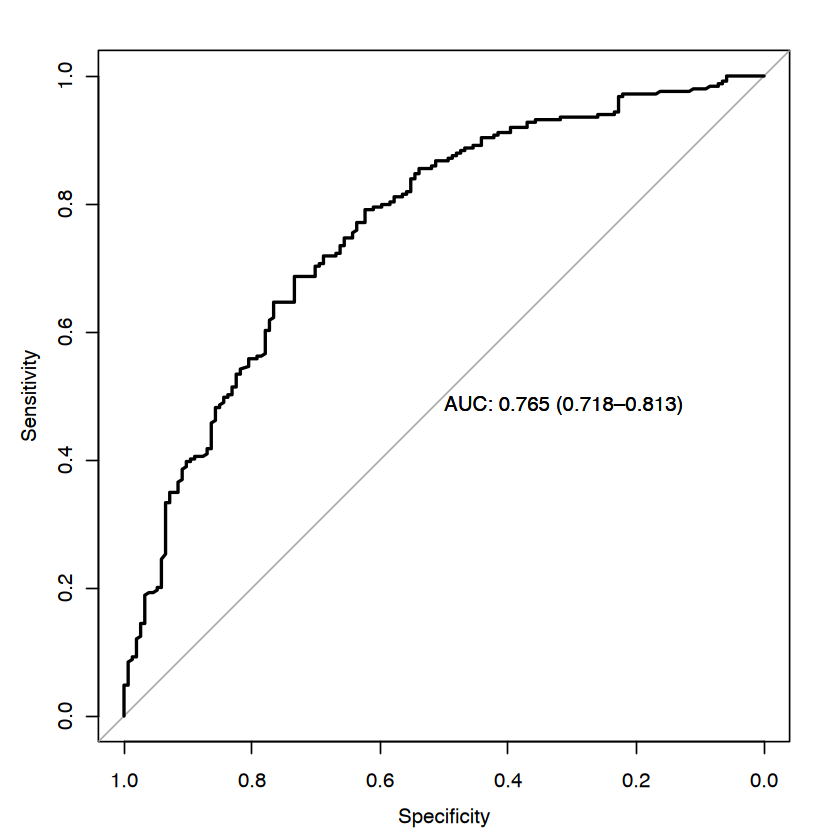

In [41]:
#Baseline model
cpep = glm(c_peptide_status ~ c_peptide_v1_z , data = df, family=binomial) 
df$cpeppred = cpep %>% predict(df, type = 'response')
roc_obj_cpep = roc(df$c_peptide_status ~ df$cpeppred, plot = TRUE, print.auc=TRUE,ci=TRUE)

dka_re = reliabilitydiag(
  fitted(dka),
  y = as.numeric(model.frame(dka)$c_peptide_status) -1
)


#DKA
dka = glm(c_peptide_status ~ c_peptide_v1_z + DKA, data = df, family=binomial) 
df$dkapred = dka %>% predict(df, type = 'response')
roc_obj_dka = roc(df$c_peptide_status ~ df$dkapred, plot = TRUE, print.auc=TRUE,ci=TRUE)

dka_re = reliabilitydiag(
  fitted(dka),
  y = as.numeric(model.frame(dka)$c_peptide_status) -1
)

#IA2 Positivity
ia2 = glm(c_peptide_status ~ c_peptide_v1_z +IA2_bin_v1, data = df, family=binomial) 
df$ia2pred = ia2 %>% predict(df, type = 'response')
roc_obj_ia2 = roc(df$c_peptide_status ~ df$ia2pred, plot = TRUE, print.auc=TRUE,ci=TRUE)

ia2_re = reliabilitydiag(
  fitted(ia2),
  y = as.numeric(model.frame(ia2)$c_peptide_status) -1
)

#GAD Titre
gad = glm(c_peptide_status ~ c_peptide_v1_z + GAD_v1_z, data = df, family=binomial) 
df$gadpred = gad %>% predict(df, type = 'response')
roc_obj_gad = roc(df$c_peptide_status ~ df$gadpred, plot = TRUE, print.auc=TRUE,ci=TRUE)

gad_re = reliabilitydiag(
  fitted(gad),
  y = as.numeric(model.frame(gad)$c_peptide_status) -1
)

#Gender Titre
gen = glm(c_peptide_status ~ c_peptide_v1_z + Gender_v1, data = df, family=binomial) 
df$genpred = gen %>% predict(df, type = 'response')
roc_obj_gen = roc(df$c_peptide_status ~ df$genpred, plot = TRUE, print.auc=TRUE,ci=TRUE)

gen_re = reliabilitydiag(
  fitted(gen),
  y = as.numeric(model.frame(gen)$c_peptide_status) -1
)



In [42]:
#Logistic regression model
log_reg = glm(c_peptide_status ~ c_peptide_v1_z + Gender_v1 +
                                IA2_bin_v1 + GAD_v1_z + DKA,
                               family = 'binomial',
                               data = df)

In [44]:
#Logistic results table
log_results = tbl_regression(log_reg ,
                              label = list(
                              c_peptide_v1_z ~ "Baseline C-peptide",
                              Gender_v1               ~ "Gender",
                              IA2_bin_v1              ~ "IA2 antibody positivity",
                              GAD_v1_z              ~ 'GAD Titre',
                             DKA ~ 'Diabetic Ketoacidosis'
                            )
                             ) %>%
       modify_caption("**Multivariable Logistic Regression**") %>%
       add_global_p() %>%
      modify_footnote(
    everything() ~ NA  
  ) %>%
  modify_table_styling(
    columns = label,
    rows = variable == "GAD_v1_z",
    footnote = "GAD: Glutamic acid decarboxylase"
  )%>%
  modify_table_styling(
    columns = label,
    rows = variable == "IA2_bin_v1",
    footnote = "IA2:Insulinoma associated Antigen 2"
  )
log_results %>% 
  as_gt() %>%
  gt::gtsave("log_results_log.png", vwidth = 800, vheight = 400)

! Reconnecting to chrome process.
ℹ All active sessions will be need to be respawned.
file:////var/folders/7l/0hx6q47x38b8ym5gd1t2x3k40000gn/T//RtmpWxigDS/filee9f33d0c026.html screenshot completed



### Visualisation

In [45]:
#Visualizing variables in full logistic model
clean_plot = function(p, xlab) {
  p + 
    labs(x = xlab, y = "Predicted probability\nof fast progression", title = NULL) +
    theme(
      axis.title.x = element_text(face = "bold", size = 13),
      axis.title.y = element_text(face = "bold", size = 13),
      axis.text = element_text(size = 12),
      plot.title = element_blank()
    )
}

d  <- clean_plot(plot(ggpredict(log_reg, terms = c("DKA"), ci_level = 0.95)), "DKA")
g  <- clean_plot(plot(ggpredict(log_reg, terms = c("Gender_v1"), ci_level = 0.95)), "Gender")
i  <- clean_plot(plot(ggpredict(log_reg, terms = c("IA2_bin_v1"), ci_level = 0.95)), "IA2 Positivity")
gt <- clean_plot(plot(ggpredict(log_reg, terms = c("GAD_v1_z [all]"), ci_level = 0.95)), "GAD Titre")

mainlog_plot <- wrap_plots(d, g, i, gt, nrow = 2, ncol = 2) +
  plot_annotation(
    title = "Predicted probabilities of fast C-peptide progression",
    tag_levels = "a"
  ) &
  theme(
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.tag = element_text(face = "bold", size = 14)
  )

ggsave("log_result_plots_2.png", mainlog_plot, width = 20, height = 10, dpi = 400)


In [ ]:
##############
#ROC AUC
###############
df$log_pred = log_reg  %>% predict(df, type = 'response')
roc_obj = roc(df$c_peptide_group ~ df$log_pred,plot = TRUE, print.auc=TRUE,ci=TRUE 
            )

#Reliability
log_re = reliabilitydiag(
  fitted(log_reg),
  y = as.numeric(model.frame(log_reg)$c_peptide_status) - 1
)

In [ ]:
png("roc_combined.png", width = 3000, height = 1500, res = 200)

par(mfrow = c(2, 3))

plot(roc_obj_dka, main = "DKA",print.auc = TRUE,ci = TRUE)
plot(roc_obj_ia2, main = "IA2 Positivity", print.auc = TRUE,ci=TRUE)
plot(roc_obj_gad, main = "GAD Titre", print.auc = TRUE,ci=TRUE)
plot(roc_obj_gen, main = "Gender", print.auc = TRUE,ci=TRUE)
plot(roc_obj, main = "DKA + GAD + IA2 + Gender", print.auc = TRUE,ci=TRUE)

dev.off()


In [ ]:

# List ROC objects 
roc_list <- list(
    'Baseline C-peptide' = roc_obj_cpep,
  "DKA" = roc_obj_dka,
  "IA2 Positivity" = roc_obj_ia2,
  "GAD Titre" = roc_obj_gad,
  "Gender" = roc_obj_gen,
  "DKA + GAD + IA2 + Gender" = roc_obj
)

#  Extract the  AUC and CI numbers 
label_data = data.frame(
  name = factor(names(roc_list), levels = names(roc_list)), 
  x = 0.25, 
  y = 0.15,
  label = sapply(roc_list, function(roc) {
    paste0("AUC: ", round(roc$auc, 2), "\n95% CI: ", round(roc$ci[1], 2), "-", round(roc$ci[3], 2))
  })
)


roc_grid = ggroc(roc_list, size = 1)
roc_grid$data$name = factor(roc_grid$data$name, levels = names(roc_list))

final_plot = roc_grid +
  geom_abline(slope = 1, intercept = 1, linetype = "dashed", color = "darkgray") +
  geom_text(data = label_data, aes(x = x, y = y, label = label), size = 4.5, fontface = "bold", inherit.aes = FALSE) +
  facet_wrap(~name, ncol = 3) + 
  labs(x = "Specificity", y = "Sensitivity") +
  theme_bw(base_size = 14) + 
  theme(legend.position = "none", strip.text = element_text(face = "bold"))

ggsave("roc_combined_ordered.png", plot = final_plot, width = 14, height = 9, dpi = 300)


In [ ]:
p_dka <- autoplot(dka_re) + ggtitle("DKA")
p_ia2 <- autoplot(ia2_re) + ggtitle("IA2 Positivity")
p_gad <- autoplot(gad_re) + ggtitle("GAD Titre")
p_gen <- autoplot(gen_re) + ggtitle("Gender")
p_log_re <- autoplot(log_re) + ggtitle("DKA + GAD + IA2 + Gender")

combined <- p_dka + p_ia2 + p_gad + p_gen + p_log_re +
  plot_layout(ncol = 5) &
  theme(plot.margin = margin(10, 15, 10, 15))

ggsave("reliability_combined.png", combined, width = 25, height = 5, dpi = 300)

